# EmporiUm Sales Territory Analysis

**Analyst:** Onur Karaer  
**Territory Manager:** Erbayne Middleton  
**Region:** Northeast  
**Territories:** Maine — Stores 818, 819, 820, 821, 822, 823  
**Cities:** Bangor, Bar Harbor, Kennebunkport, Lewiston, Orono, South Portland  
**Data Period:** 2022–2025  

## Project Description
This notebook analyzes in-store sales performance for the territories assigned 
to Erbayne Middleton in the Northeast region. The analysis covers monthly revenue 
trends, store performance rankings, top customers, and product category insights, 
concluding with a marketing recommendation for the next quarter.

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [54]:
store_sales = pd.read_csv('StoreSales (1).csv')
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [55]:
store_detail = pd.read_csv('StoreDetail (1).csv')
store_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [56]:
products = pd.read_csv('Products (3).csv')
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [57]:
product_categories = pd.read_csv('ProductCategories (1).csv')
product_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [58]:
customer_list = pd.read_csv('customer_list (1).csv', sep='|') #Columns are seperated with bar instead of commas in this file
customer_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [59]:
print(store_sales.head(3))
print(store_detail.head(3))
print(products.head(3))
print(product_categories.head(3))
print(customer_list.head(3))

  Transaction Date  Store ID  RewardsID  Prod Num  Sale Amount
0         1/1/2022       702        NaN  105349-M          8.0
1         1/1/2022       704        NaN  105350-T        144.0
2         1/1/2022       705        NaN  105351-M         44.0
  Store Location     State  Store ID Territory Manager Region  Region Director
0         Aurora  Colorado       701          Jim Heck   West  Cassie Chambers
1       Berthoud  Colorado       702          Jim Heck   West  Cassie Chambers
2        Boulder  Colorado       703          Jim Heck   West  Cassie Chambers
    Prod Num                        Product  CategoryID SubcategoryID
0  105248-IT               TCL NXTPAPER 10s         120       120-tab
1  105249-IT  Dell Latitude 7320 Detachable         120       120-tab
2  105250-IT                     Realme Pad         120       120-tab
   CategoryID                  Category SubcategoryID        Subcategory
0         120  Technology & Accessories       120-tab            Tablets
1     

# Core Marketing Analysis

The following analysis addresses key questions from the marketing manager 
for the two sales territories assigned to Erbayne Middleton in the 
Northeast region (Maine). Analysis covers stores 818–823 across 
Bangor, Bar Harbor, Kennebunkport, Lewiston, Orono, and South Portland.

In [60]:
store_detail[store_detail['Territory Manager'] == 'Erbayne Middleton'] #Checking the stores belong to me.

,Store Location,State,Store ID,Territory Manager,Region,Region Director
37,Bangor,Maine,818,Erbayne Middleton,Northeast,Michael Jarvis
38,Bar Harbor,Maine,819,Erbayne Middleton,Northeast,Michael Jarvis
39,Kennebunkport,Maine,820,Erbayne Middleton,Northeast,Michael Jarvis
40,Lewiston,Maine,821,Erbayne Middleton,Northeast,Michael Jarvis
41,Orono,Maine,822,Erbayne Middleton,Northeast,Michael Jarvis
42,South Portland,Maine,823,Erbayne Middleton,Northeast,Michael Jarvis


In [61]:
store_detail[store_detail['Region'] == 'Northeast']['Territory Manager'].unique() #Checking the other managers in the Northeast region.

<StringArray>
['Erbayne Middleton', 'Shruti Reddy', 'Bo Heap', 'Miami Vue']
Length: 4, dtype: str

In [62]:
store_detail[store_detail['Region'] == 'Northeast'].groupby('Territory Manager')['Store ID'].count() #Checking how many stores other managers have. I will pick
                                                                                                    #Shruti Reddy as a comparision point since numbers of stores and
                                                                                                    #the size of the state is the closest to me.

Territory Manager
Bo Heap              18
Erbayne Middleton     6
Miami Vue            16
Shruti Reddy          9
Name: Store ID, dtype: int64

## Territory Selection

This analysis compares two sales territories in the Northeast region:

- **Territory 1:** Erbayne Middleton: Maine (Stores 818–823)
- **Territory 2:** Shruti Reddy: Selected as comparison territory due to similar store count (9 stores) within the same Northeast region

Both territories will be analyzed side by side throughout this report.

## Question 1: Territory Managers and Store Information

Who are the territory managers for the assigned sales territories? 
What are the store IDs and cities for the stores in each territory?

In [72]:
# Filter stores for both territories
erbayne_stores = store_detail[store_detail['Territory Manager'] == 'Erbayne Middleton']
shruti_stores = store_detail[store_detail['Territory Manager'] == 'Shruti Reddy']

# Display store information for each territory. I only selected the columns below to display. Micheal Jarvis is the region director for all the stores that I am analyzing.
print("Territory 1: Erbayne Middleton")
print(erbayne_stores[['Store ID', 'Store Location', 'State', 'Territory Manager', 'Region']])

print("Territory 2: Shruti Reddy")
print(shruti_stores[['Store ID', 'Store Location', 'State', 'Territory Manager', 'Region']])

Territory 1: Erbayne Middleton
    Store ID  Store Location  State  Territory Manager     Region
37       818          Bangor  Maine  Erbayne Middleton  Northeast
38       819      Bar Harbor  Maine  Erbayne Middleton  Northeast
39       820   Kennebunkport  Maine  Erbayne Middleton  Northeast
40       821        Lewiston  Maine  Erbayne Middleton  Northeast
41       822           Orono  Maine  Erbayne Middleton  Northeast
42       823  South Portland  Maine  Erbayne Middleton  Northeast
Territory 2: Shruti Reddy
    Store ID       Store Location     State Territory Manager     Region
43       731            Annapolis  Maryland      Shruti Reddy  Northeast
44       732           Back River  Maryland      Shruti Reddy  Northeast
45       733            Baltimore  Maryland      Shruti Reddy  Northeast
46       734           Germantown  Maryland      Shruti Reddy  Northeast
47       735               Howard  Maryland      Shruti Reddy  Northeast
48       736        North Harford  Maryland

## Question 2: Monthly Total Revenue by Territory

What is the monthly total revenue for in-store sales in each of the 
two sales territories over the full period covered by the data?

In [73]:
# Filter sales for each territory
erbayne_sales = store_sales[store_sales['Store ID'].isin(erbayne_stores['Store ID'])] #.isin() works like WHERE Store ID IN (..) in SQL
shruti_sales = store_sales[store_sales['Store ID'].isin(shruti_stores['Store ID'])]     #So i only pulled the sales data from stores that i am assigned to.

#I previously got SettingWithCopyWarning when i tried to add columns as in the following steps
#I need to copy the filtered dataframe above to create a new data frame. So I can add new columns on that.
erbayne_sales = erbayne_sales.copy()
shruti_sales = shruti_sales.copy()

# Converted Transaction Date to datetime. Because the time information in the original sales file recorded as STR.
erbayne_sales['Transaction Date'] = pd.to_datetime(erbayne_sales['Transaction Date'])
shruti_sales['Transaction Date'] = pd.to_datetime(shruti_sales['Transaction Date'])

# Create Year-Month column. I excluded day information. I will do my analyze based on MM-YYYY information.
erbayne_sales['YearMonth'] = erbayne_sales['Transaction Date'].dt.to_period('M')
shruti_sales['YearMonth'] = shruti_sales['Transaction Date'].dt.to_period('M')

# Group by YearMonth and sum revenue
erbayne_monthly = erbayne_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()
shruti_monthly = shruti_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()

erbayne_monthly.columns = ['YearMonth', 'Total Revenue']
shruti_monthly.columns = ['YearMonth', 'Total Revenue']

print("Territory 1: Erbayne Middleton - Monthly Revenue")
print(erbayne_monthly)

print("Territory 2: Shruti Reddy - Monthly Revenue")
print(shruti_monthly)

Territory 1: Erbayne Middleton - Monthly Revenue
   YearMonth  Total Revenue
0    2022-01       15700.31
1    2022-02       21008.29
2    2022-03       23173.23
3    2022-04       20169.19
4    2022-05       22631.11
5    2022-06       31573.93
6    2022-07       19371.11
7    2022-08       27979.07
8    2022-09       27393.30
9    2022-10       24947.09
10   2022-11       19783.08
11   2022-12       25345.23
12   2023-01       41331.95
13   2023-02       37650.30
14   2023-03       36162.92
15   2023-04       35875.41
16   2023-05       26201.22
17   2023-06       30183.66
18   2023-07       44731.17
19   2023-08       42202.08
20   2023-09       44862.59
21   2023-10       34905.29
22   2023-11       35428.88
23   2023-12       41279.32
24   2024-01       43881.68
25   2024-02       31494.48
26   2024-03       36311.69
27   2024-04       25764.94
28   2024-05       31426.20
29   2024-06       43488.63
30   2024-07       42202.08
31   2024-08       46505.54
32   2024-09       33262.34

In [74]:
erbayne_sales['Year'] = erbayne_sales['Transaction Date'].dt.year #Revenue per year from Shruti's stores
erbayne_yearly = erbayne_sales.groupby('Year')['Sale Amount'].sum().reset_index()
erbayne_yearly.columns = ['Year', 'Total Revenue']
print('Erbayne Yearly Revenue')
print(erbayne_yearly)

shruti_sales['Year'] = shruti_sales['Transaction Date'].dt.year #Revenue per year from Shruti's stores
shruti_yearly = shruti_sales.groupby('Year')['Sale Amount'].sum().reset_index()
shruti_yearly.columns = ['Year', 'Total Revenue']
print('Shruti Yearly Revenue')
print(shruti_yearly)

Erbayne Yearly Revenue
   Year  Total Revenue
0  2022      279074.94
1  2023      450814.79
2  2024      452377.73
3  2025      694982.29
Shruti Yearly Revenue
   Year  Total Revenue
0  2022     2409967.70
1  2023     2813693.20
2  2024     2821691.59
3  2025     3406262.60


- Maryland stores are significantly generating more revenue compared to Maine stores almost 10x in 2022 and around 5x in 2025.
- This difference cannot be explained by store count alone. Maine has 6 stores, Maryland has 9.
- The likely explanation is the population size and income levels of the cities where these stores are located.
- Also the gap between the territories is closing. I want to see if we opened up new stores or closed existing ones.
- Below, I tested whether my arguments are true or false

In [75]:
# Total population for each territory (2024 US Census estimates). I got help from researching the populations in my assisgned territories.!!!
erbayne_population = {'Territory': 'Erbayne Middleton', 'State': 'Maine', 'Total Population': 117775}
shruti_population = {'Territory': 'Shruti Reddy', 'State': 'Maryland', 'Total Population': 1160968}

# Revenue per capita
erbayne_rpc = erbayne_total_rev / erbayne_population['Total Population']
shruti_rpc = shruti_total_rev / shruti_population['Total Population']

print("Population & Revenue Per Capita Comparison")
print(f"Erbayne Middleton (Maine):")
print(f"Total Population:{erbayne_population['Total Population']:,}")
print(f"Total Revenue: ${erbayne_total_rev:,.2f}")
print(f"Revenue Per Capita:${erbayne_rpc:.2f}")

print(f"Shruti Reddy (Maryland):")
print(f"Total Population: {shruti_population['Total Population']:,}")
print(f"Total Revenue: ${shruti_total_rev:,.2f}")
print(f"Revenue Per Capita: ${shruti_rpc:.2f}")

Population & Revenue Per Capita Comparison
Erbayne Middleton (Maine):
Total Population:117,775
Total Revenue: $1,877,249.75
Revenue Per Capita:$15.94
Shruti Reddy (Maryland):
Total Population: 1,160,968
Total Revenue: $11,451,615.09
Revenue Per Capita: $9.86


## Key Findings: Population & Revenue Per Capita

- The revenue difference between the two territories is mainly driven by population size. The larger the market, the higher the total revenue.
- However, income level is **not** the source of this difference. Maine's revenue per capita is actually **higher** than Maryland's, suggesting stronger individual customer engagement in Erbayne's territory despite the smaller population.

In [67]:
print(erbayne_sales.groupby('Store ID')['YearMonth'].nunique()) #Checking if we have recorded sales from these stores for 48 months.
print(shruti_sales.groupby('Store ID')['YearMonth'].nunique())

Store ID
818    48
819    48
820    48
821    48
822    48
823    48
Name: YearMonth, dtype: int64
Store ID
731    48
732    48
733    48
734    48
735    48
736    48
737    48
738    48
739    48
Name: YearMonth, dtype: int64


- **Store Activity**

- EmporiUm haven't opened up new stores or closed down the existing stores in our territories. 
- So, the closing revenue gap between the territories is not based on the store numbers.

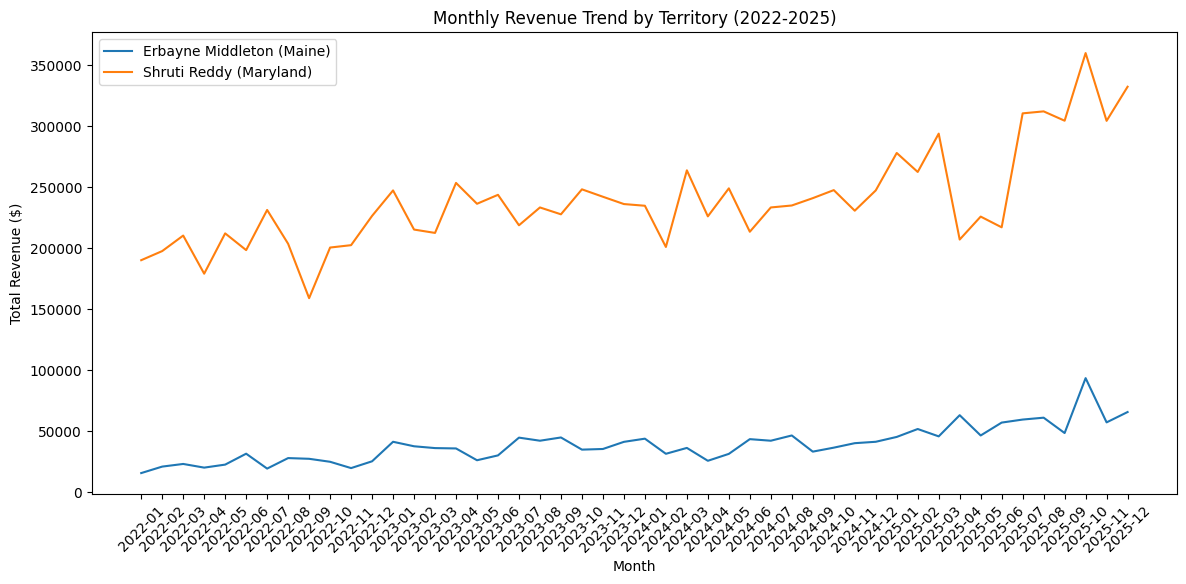

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(erbayne_monthly['YearMonth'].astype(str),erbayne_monthly['Total Revenue'],label='Erbayne Middleton (Maine)')
plt.plot(shruti_monthly['YearMonth'].astype(str),shruti_monthly['Total Revenue'],label='Shruti Reddy (Maryland)')

plt.title('Monthly Revenue Trend by Territory (2022-2025)')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

- Both stores are showing an **upwards** trend. 
- The **dips** in August 2022 and March-May 2025 in Maryland should be analayzed.
- The **peaks** in October 2025 in both stores also should be analyzed
- Maine's **revenue per capita is higher** than Maryland's, meaning stronger individual customer engagement despite the smaller market size.
- Maine grew **149%** from 2022 to 2025, while Maryland grew only **41%** Maine is expanding at a significantly faster rate.
- The **revenue gap is closing**  Maine was 10x smaller than Maryland in 2022, but only 5x smaller by 2025.

## Question 3: Store Performance Ranking

How would you rank the sales performance of each store in each sales territory? 
Which are the top-performing stores?

In [80]:
# Total revenue per store
erbayne_store_rev = erbayne_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
shruti_store_rev = shruti_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()

# Add store names
erbayne_store_rev = erbayne_store_rev.merge(store_detail[['Store ID', 'Store Location']], on='Store ID')
shruti_store_rev = shruti_store_rev.merge(store_detail[['Store ID', 'Store Location']], on='Store ID')

# Rank by revenue
erbayne_store_rev = erbayne_store_rev.sort_values('Sale Amount', ascending=False)
shruti_store_rev = shruti_store_rev.sort_values('Sale Amount', ascending=False)

print("Erbayne Middleton - Store Rankings")
print(erbayne_store_rev[['Store Location', 'Sale Amount']])

print("Shruti Reddy - Store Rankings")
print(shruti_store_rev[['Store Location', 'Sale Amount']])

Erbayne Middleton - Store Rankings
   Store Location  Sale Amount
5  South Portland    332611.76
4           Orono    330505.47
2   Kennebunkport    321998.55
3        Lewiston    303761.91
0          Bangor    300919.98
1      Bar Harbor    287452.08
Shruti Reddy - Store Rankings
        Store Location  Sale Amount
5        North Harford   8708119.00
3           Germantown    584675.92
6            Parkville    320441.24
4               Howard    319394.58
8              Ridgely    318511.04
2            Baltimore    310099.90
1           Back River    303433.61
7  Queen Anne's County    298074.49
0            Annapolis    288865.31


- **North Harford** stands out in Maryland territory with $8.7M total revenue.
- This seem like the biggest revenue difference between territories.
- Why this store is generating much larger revenues compare to others? I need to analyze!
- In Erbayne's territory, stores are relatively **balanced** in performance. Top store South Portland ($332K) and bottom store Bar Harbor ($287K) are close in revenue.


In [81]:
#Trying to see what is going on in North Harford
north_harford_sales = shruti_sales[shruti_sales['Store ID'] == 736]
print(north_harford_sales['Sale Amount'].describe())
print(north_harford_sales.sort_values('Sale Amount', ascending=False).head(10))

#I checked the overall data in all stores in my territories.
print(shruti_sales.groupby('Store ID')['Sale Amount'].describe())
print(erbayne_sales.groupby('Store ID')['Sale Amount'].describe())

print(shruti_sales.groupby('Store ID').size()/48)
print(erbayne_sales.groupby('Store ID').size()/48)

count    69530.000000
mean       125.242615
std        265.532395
min          2.400000
25%         15.350000
50%         28.880000
75%        108.330000
max       1763.700000
Name: Sale Amount, dtype: float64
       Transaction Date  Store ID  RewardsID   Prod Num  Sale Amount  \
213935       2025-01-11       736        NaN  105341-IT       1763.7   
127941       2023-12-08       736      371.0  105341-IT       1763.7   
131904       2023-12-26       736      479.0  105341-IT       1763.7   
28492        2022-07-06       736      145.0  105341-IT       1763.7   
216452       2025-01-19       736        NaN  105341-IT       1763.7   
221618       2025-02-04       736        NaN  105341-IT       1763.7   
29535        2022-07-13       736        NaN  105341-IT       1763.7   
28645        2022-07-07       736        NaN  105341-IT       1763.7   
56167        2023-01-02       736        NaN  105341-IT       1763.7   
233218       2025-03-13       736        NaN  105341-IT       1763.7  

In [71]:
#Checking if there are duplicate records for North Harford
print(north_harford_sales.duplicated().sum())

0


- I checked the summary statistics for all stores. 
- I checked if there are duplicates for North Harford but there are none.
- One data got my attention. All the stores are generating appx. 45 transaction per month.
- Only Germantown (Store 734) in Maryland is generating 90 transaction per month.
- But North Harford is generating appx. **1450** transaction per month!! 